<a href="https://colab.research.google.com/github/mdtanjimhasanashik/DeepGene-TB/blob/main/DeepGene_TB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
Final_DEGs=pd.read_csv("/content/drive/MyDrive/Data_Set/DENV_gene/DEGs_set.csv")
Final_DEGs

,Unnamed: 0.1,Unnamed: 0,Gene,0,1,2,3,4,5,6,...,2238,2239,2240,2241,2242,2243,log2fc,p_value,adj_p_value,target
0,0,0,FGR,0.0000,0.0000,0.0000,0.000,2.9110,16.9374,0.000,...,19.8922,18.1169,0.0000,0.0,0.0000,8.6683,2.312334,1.424200e-08,3.656048e-07,1.0
1,1,1,ENPP4,2.8671,11.4588,0.0000,0.000,13.4420,0.0000,0.000,...,0.8117,0.0000,60.5167,0.0,0.0000,0.0000,1.055971,3.509842e-02,4.016773e-02,1.0
2,2,2,ST7,9.6391,44.6741,48.9423,50.224,45.3135,0.0000,87.121,...,0.0000,9.3375,15.3363,0.0,4.3941,7.8650,-1.883971,1.298770e-05,1.371826e-04,0.0
3,3,3,OSBPL7,0.0000,0.3913,10.5258,0.000,6.4898,1.5395,0.000,...,279.1432,6.5387,0.6939,0.0,2.4243,2.8046,-1.201447,3.824219e-04,1.882407e-03,0.0
4,4,4,CACNG3,0.0000,0.8965,0.0000,0.000,2.4045,0.0000,0.000,...,0.0000,0.8075,0.0000,0.0,0.0000,0.0000,-1.255598,1.077081e-04,7.161705e-04,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,2023,2023,MIR7515,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.000,...,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,2.000880,4.434787e-02,4.647932e-02,1.0
2024,2024,2024,LOC101929989,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.000,...,0.0000,0.0000,32.7870,0.0,0.0000,0.0000,-1.143389,4.102652e-02,4.439796e-02,0.0
2025,2025,2025,ACR.1,0.0000,0.0000,0.0000,0.228,0.0000,2.0852,0.000,...,0.0000,0.0000,0.0000,0.0,2.5423,0.3553,-1.120220,1.215591e-02,2.073354e-02,0.0
2026,2026,2026,SYT14.1,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.000,...,0.0000,9.1070,0.0000,0.0,0.0000,0.0000,-1.124801,5.214655e-03,1.205852e-02,0.0


In [ ]:
Final_DEGs['target'].value_counts()

,count
target,
0.0,1816
1.0,212


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
DGEs =Final_DEGs.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtype == 'object' else col)

In [ ]:
print(DGEs .isnull().sum())  # Check for missing values

Unnamed: 0.1    0
Unnamed: 0      0
Gene            0
0               0
1               0
               ..
2243            0
log2fc          0
p_value         0
adj_p_value     0
target          0
Length: 2251, dtype: int64


In [ ]:
X = DGEs.iloc[:, :-1].astype(float).values

In [ ]:
X= DGEs.iloc[:, :-1].values
y = DGEs.iloc[:, -1].values

In [ ]:
# Encode labels (if categorical)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler to X_res and transform
x = scaler.fit_transform(X)

# Print the shape to confirm
print("X_scaled shape:", x.shape)

X_scaled shape: (2028, 2250)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1622, 2250)
X_val shape: (203, 2250)
X_test shape: (203, 2250)
y_train shape: (1622,)
y_val shape: (203,)
y_test shape: (203,)


In [ ]:
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Show shapes and new class distribution
print("Original y_train shape:", y_train.shape)
print("Resampled y_train shape:", y_train_resampled.shape)

# Optionally, check the distribution
from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))

Original y_train shape: (1622,)
Resampled y_train shape: (2904,)
Before SMOTE: Counter({np.int64(0): 1452, np.int64(1): 170})
After SMOTE: Counter({np.int64(0): 1452, np.int64(1): 1452})


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Fold 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.8139 - loss: 2.3881 - val_accuracy: 0.6598 - val_loss: 2.0706 - learning_rate: 0.0010
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.9565 - loss: 1.5755 - val_accuracy: 0.6254 - val_loss: 1.8435 - learning_rate: 0.0010
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9537 - loss: 1.1914 - val_accuracy: 0.5945 - val_loss: 1.9963 - learning_rate: 0.0010
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9672 - loss: 1.0062 - val_accuracy: 0.6907 - val_loss: 1.6352 - learning_rate: 0.0010
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9586 - loss: 0.9299 - val_accuracy: 0.7010 - val_loss: 1.5619 - learning_rate: 0.0010
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9672 - loss: 0.7765 - val_accuracy: 0.7560 - val_loss: 1.2084 - learning_rate: 0.0010
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9558 - loss: 0.7802

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - accuracy: 0.8462 - loss: 2.2285 - val_accuracy: 0.5326 - val_loss: 3.0882 - learning_rate: 0.0010
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9569 - loss: 1.4999 - val_accuracy: 0.5086 - val_loss: 4.2512 - learning_rate: 0.0010
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9552 - loss: 1.2130 - val_accuracy: 0.5773 - val_loss: 2.8090 - learning_rate: 0.0010
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9572 - loss: 1.0423 - val_accuracy: 0.9381 - val_loss: 1.1658 - learning_rate: 0.0010
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9577 - loss: 0.9109 - val_accuracy: 0.8076 - val_loss: 1.1148 - learning_rate: 0.0010
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9588 - loss: 0.8370 - val_accuracy: 0.8213 - val_loss: 1.0067 - learning_rate: 0.0010
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9642 - loss: 0.7354 - val_accura

...

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - accuracy: 0.8485 - loss: 2.1949 - val_accuracy: 0.5172 - val_loss: 3.3777 - learning_rate: 0.0010
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9665 - loss: 1.5732 - val_accuracy: 0.5034 - val_loss: 4.1381 - learning_rate: 0.0010
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9435 - loss: 1.3137 - val_accuracy: 0.6034 - val_loss: 1.7776 - learning_rate: 0.0010
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9624 - loss: 1.0567 - val_accuracy: 0.7172 - val_loss: 1.5830 - learning_rate: 0.0010
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9665 - loss: 0.9513 - val_accuracy: 0.6897 - val_loss: 1.9670 - learning_rate: 0.0010
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9660 - loss: 0.8051 - val_accuracy: 0.7034 - val_loss: 1.5385 - learning_rate: 0.0010
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9566 - loss: 0.8174 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 155ms/step - accuracy: 0.8422 - loss: 2.3812 - val_accuracy: 0.5828 - val_loss: 3.1274 - learning_rate: 0.0010
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9496 - loss: 1.6199 - val_accuracy: 0.5828 - val_loss: 6.7552 - learning_rate: 0.0010
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9600 - loss: 1.2611 - val_accuracy: 0.6724 - val_loss: 4.2892 - learning_rate: 0.0010
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9602 - loss: 1.0863 - val_accuracy: 0.8069 - val_loss: 1.5483 - learning_rate: 0.0010
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9574 - loss: 0.9434 - val_accuracy: 0.8034 - val_loss: 1.5292 - learning_rate: 0.0010
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9633 - loss: 0.8863 - val_accuracy: 0.8414 - val_loss: 1.1278 - learning_rate: 0.0010
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9550 - loss: 0.8074 - val_accura

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step - accuracy: 0.8314 - loss: 2.2388 - val_accuracy: 0.5655 - val_loss: 2.7527 - learning_rate: 0.0010
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9602 - loss: 1.5346 - val_accuracy: 0.6379 - val_loss: 1.9952 - learning_rate: 0.0010
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9508 - loss: 1.2278 - val_accuracy: 0.8172 - val_loss: 1.3282 - learning_rate: 0.0010
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9579 - loss: 1.0459 - val_accuracy: 0.7103 - val_loss: 1.6742 - learning_rate: 0.0010
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9534 - loss: 1.0782 - val_accuracy: 0.8345 - val_loss: 1.1313 - learning_rate: 0.0010
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9640 - loss: 0.8908 - val_accuracy: 0.7966 - val_loss: 1.0518 - learning_rate: 0.0010
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9664 - loss: 0.7991 - val_accura

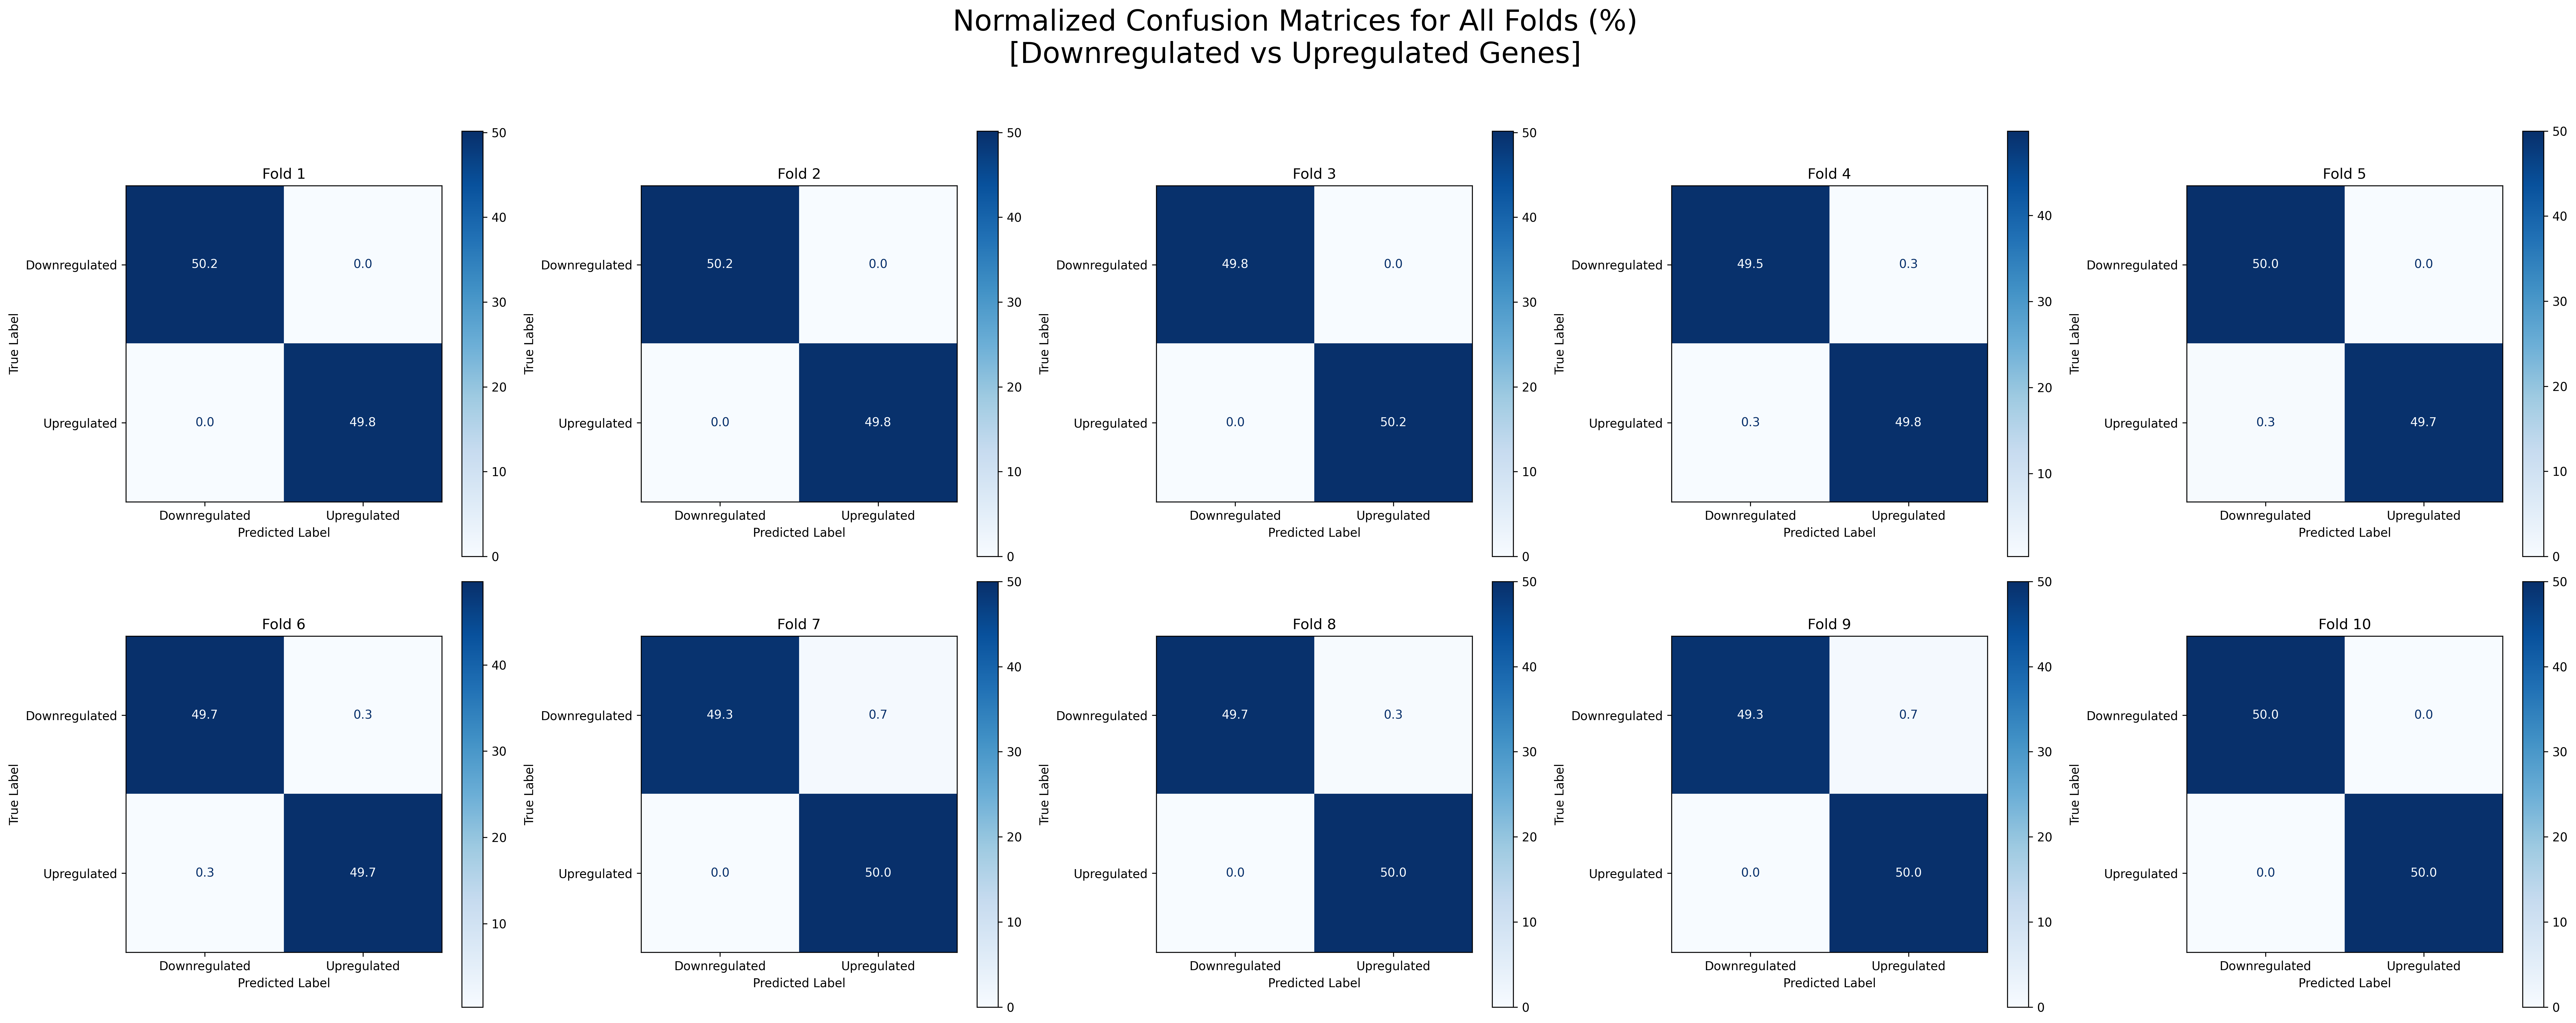

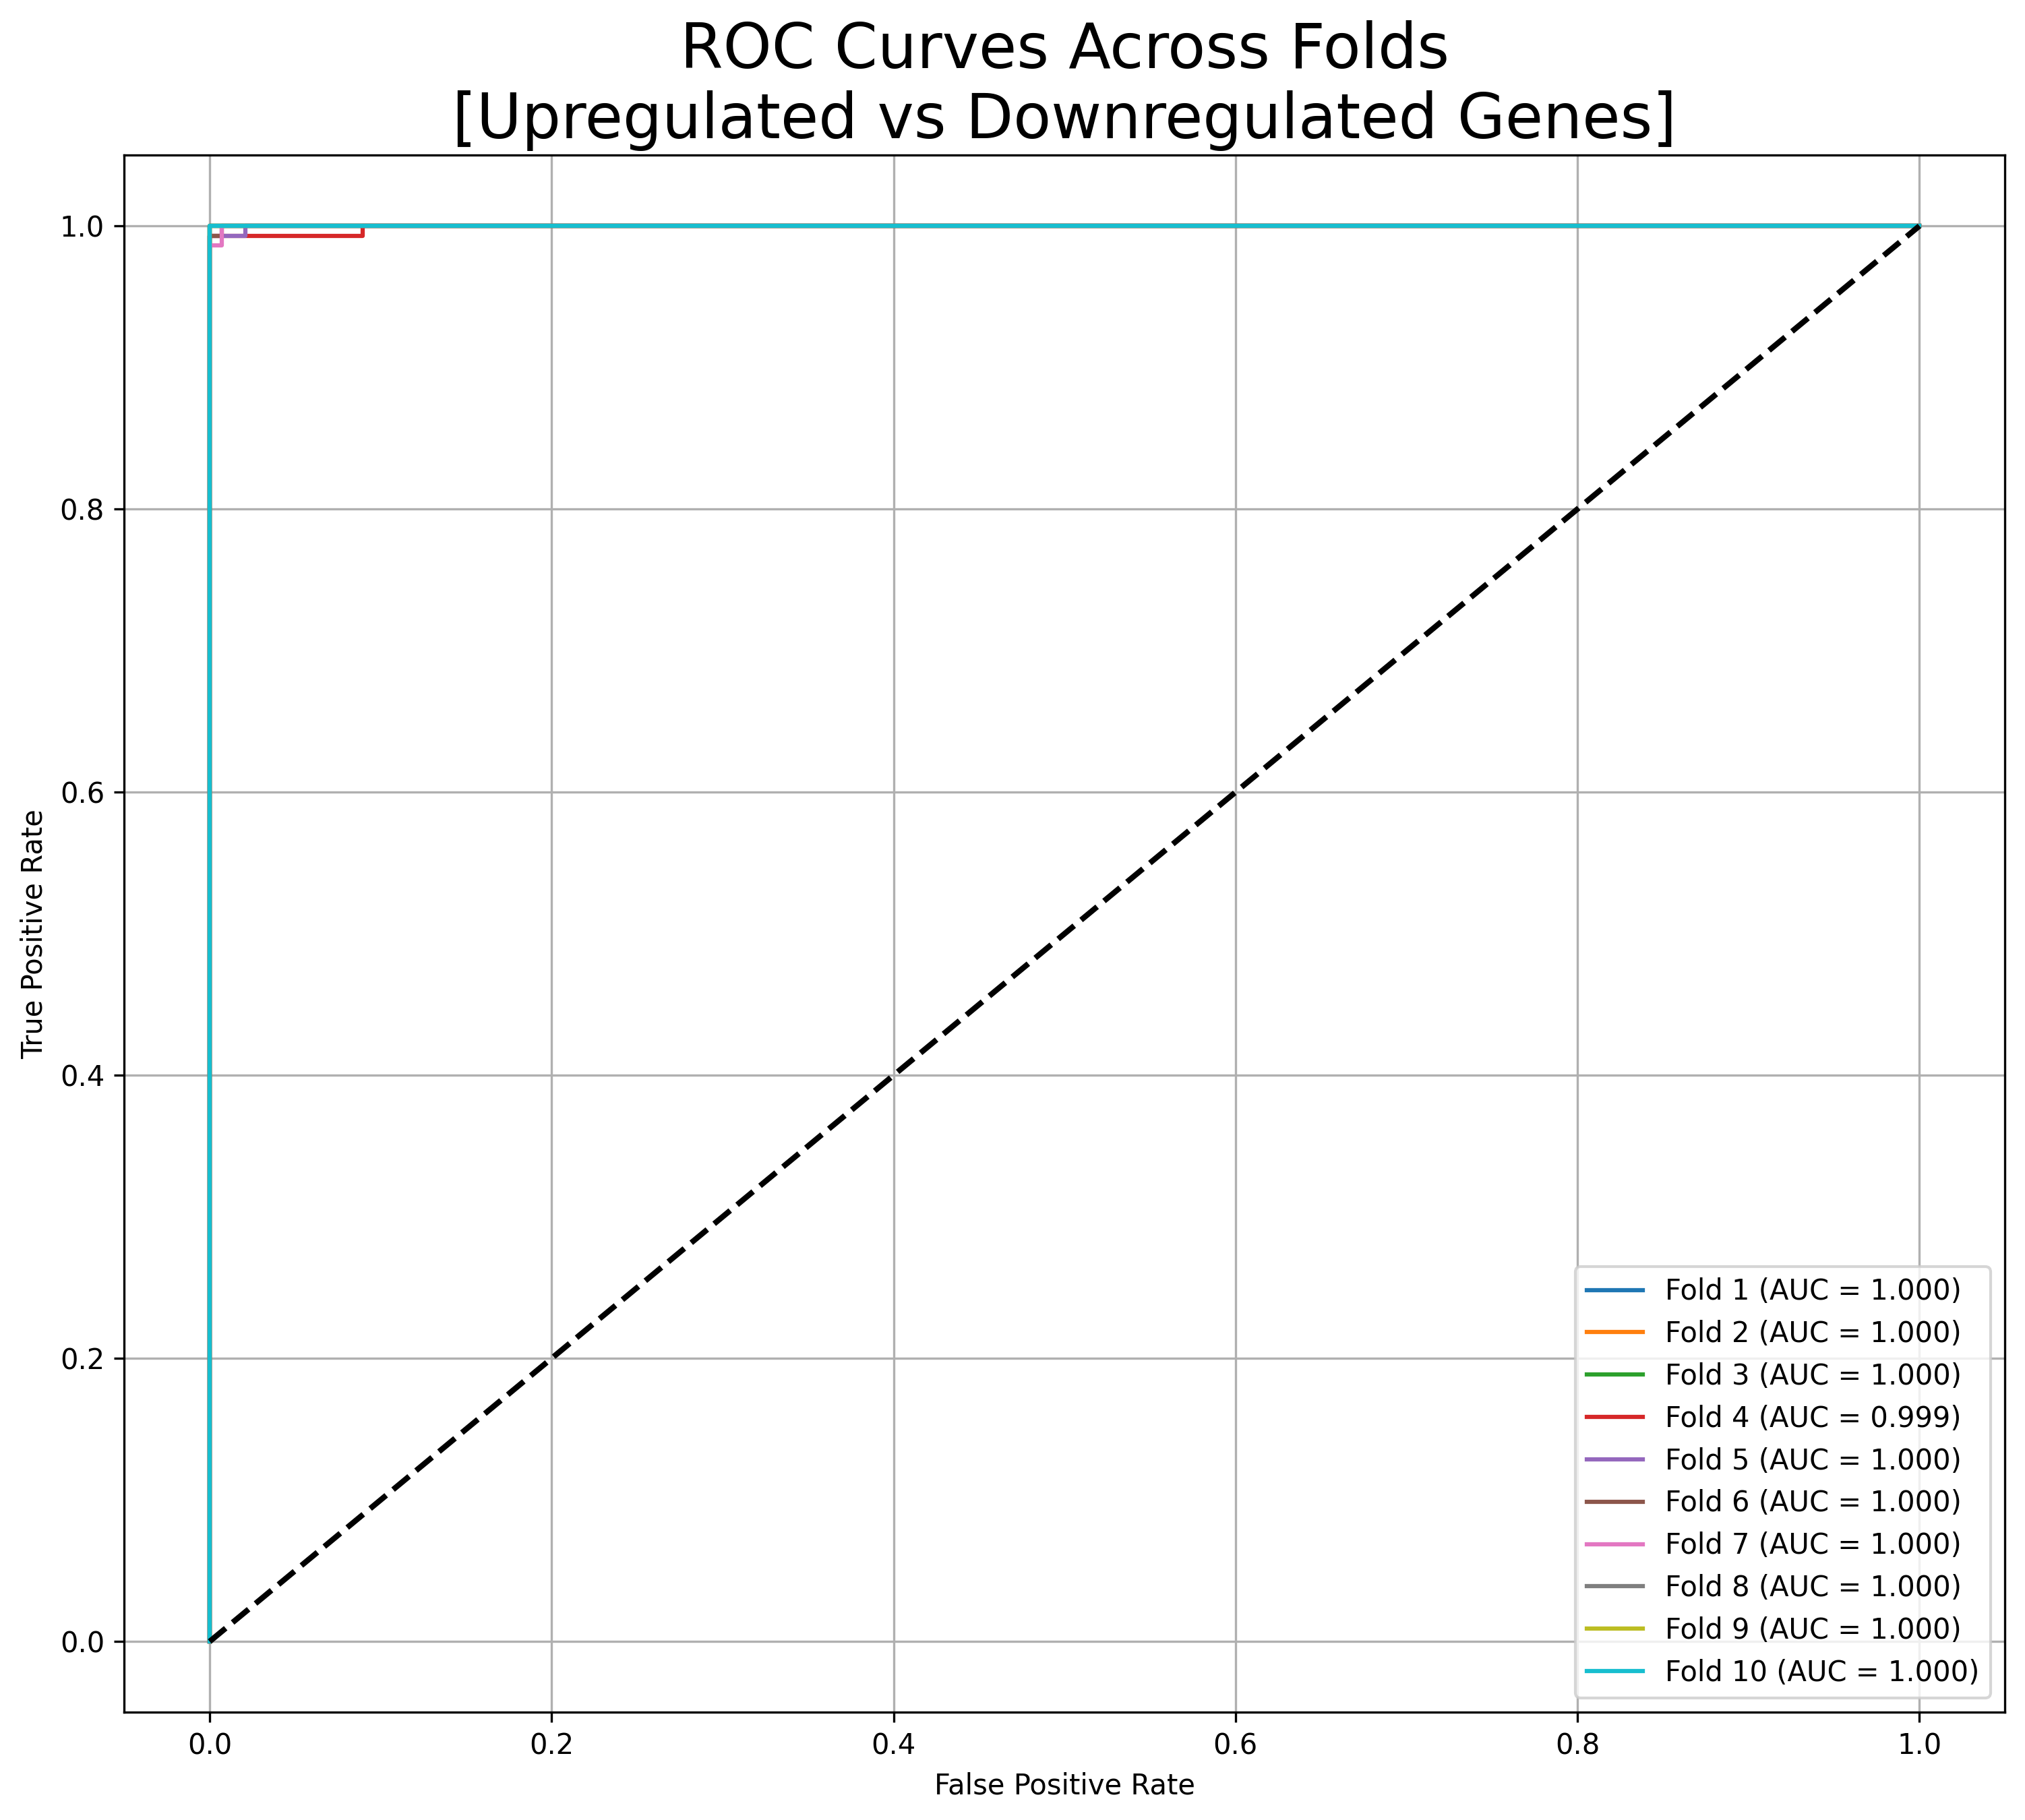


📈 Average Evaluation Metrics Across Folds:
Precision         : 0.9952 ± 0.0053
Recall            : 0.9979 ± 0.0032
F1 Score          : 0.9966 ± 0.0031
Specificity       : 0.9952 ± 0.0054
Cohen's Kappa     : 0.9931 ± 0.0062
Accuracy          : 0.9966 ± 0.0031
AUC               : 0.9999 ± 0.0002
✅ Metrics saved to Google Drive as cnn_metrics_per_fold.csv


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                             precision_score, recall_score, f1_score, cohen_kappa_score, roc_auc_score)
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.callbacks import ReduceLROnPlateau
from google.colab import drive
import pandas as pd
import os



X = X_train_resampled
y = y_train_resampled

# ---------------------- Cross-Validation Setup ----------------------
n_folds = 10
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

y_true_all, y_pred_all, y_prob_all = [], [], []
precision_scores, recall_scores, f1_scores = [], [], []
specificity_scores, kappa_scores, auc_scores, accuracy_scores = [], [], [], []

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# ---------------------- Cross-Validation Loop ----------------------
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'\nFold {fold + 1}/{n_folds}')
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
# Build CNN Model
    model = Sequential([
        Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1], 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(256, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(512, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train model
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[reduce_lr],
        verbose=1
    )

    # Predictions
    y_pred_prob = model.predict(X_val).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    y_true_all.append(y_val)
    y_pred_all.append(y_pred)
    y_prob_all.append(y_pred_prob)

    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    kappa = cohen_kappa_score(y_val, y_pred)
    auc_val = roc_auc_score(y_val, y_pred_prob)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    specificity_scores.append(specificity)
    kappa_scores.append(kappa)
    auc_scores.append(auc_val)
    accuracy_scores.append(accuracy)

    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")

# ---------------------- SAVE INDIVIDUAL CONFUSION MATRICES ----------------------
individual_cm_dir = '/content/drive/My Drive/DEG project/confusion_matrices_per_fold'
os.makedirs(individual_cm_dir, exist_ok=True)

class_labels = ["Downregulated", "Upregulated"]

for i in range(n_folds):
    cm = confusion_matrix(y_true_all[i], y_pred_all[i])
    cm_percent = cm.astype('float') / cm.sum() * 100

    fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_labels)
    disp.plot(ax=ax, cmap='Blues', values_format=".1f", colorbar=True)

    ax.set_title(f'Fold {i+1} - Normalized Confusion Matrix', fontsize=14)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_ylim(1.5, -0.5)

    fig.savefig(os.path.join(individual_cm_dir, f'confusion_matrix_fold_{i+1}.png'), dpi=300, bbox_inches='tight')
    plt.close(fig)

print(f"✅ Individual confusion matrices saved to: {individual_cm_dir}")

# ---------------------- COMBINED CONFUSION MATRIX GRID ----------------------
fig_cm_all, axs_cm = plt.subplots(2, 5, figsize=(30, 12), dpi=300)
axs_cm = axs_cm.ravel()

for i in range(n_folds):
    cm = confusion_matrix(y_true_all[i], y_pred_all[i])
    cm_percent = cm.astype('float') / cm.sum() * 100
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_labels)
    disp.plot(ax=axs_cm[i], cmap='Blues', values_format=".1f", colorbar=True)

    axs_cm[i].set_title(f'Fold {i+1}')
    axs_cm[i].set_xlabel('Predicted Label')
    axs_cm[i].set_ylabel('True Label')
    axs_cm[i].set_ylim(1.5, -0.5)

plt.suptitle('Normalized Confusion Matrices for All Folds (%)\n[Downregulated vs Upregulated Genes]', fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/content/drive/My Drive/DEG project/confusion_matrices_all_folds.png', dpi=300)
plt.show()

# ---------------------- ROC CURVES ----------------------
plt.figure(figsize=(12, 10), dpi=300)
for i in range(n_folds):
    fpr, tpr, _ = roc_curve(y_true_all[i], y_prob_all[i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Fold {i+1} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curves Across Folds\n[Upregulated vs Downregulated Genes]', fontsize=22)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('/content/drive/My Drive/DEG project/roc_curves_all_folds.png', dpi=300)
plt.show()

# ---------------------- METRIC SUMMARY ----------------------
def summarize(name, values):
    print(f"{name:<18}: {np.mean(values):.4f} ± {np.std(values):.4f}")

print("\n📈 Average Evaluation Metrics Across Folds:")
summarize("Precision", precision_scores)
summarize("Recall", recall_scores)
summarize("F1 Score", f1_scores)
summarize("Specificity", specificity_scores)
summarize("Cohen's Kappa", kappa_scores)
summarize("Accuracy", accuracy_scores)
summarize("AUC", auc_scores)

# ---------------------- SAVE TO CSV ----------------------
metrics_df = pd.DataFrame({
    "Fold": np.arange(1, n_folds+1),
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1 Score": f1_scores,
    "Specificity": specificity_scores,
    "Cohen's Kappa": kappa_scores,
    "Accuracy": accuracy_scores,
    "AUC": auc_scores
})

metrics_df.to_csv("/content/drive/My Drive/DEG project/cnn_metrics_per_fold.csv", index=False)
print("✅ Metrics saved to Google Drive as cnn_metrics_per_fold.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Fold 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step - accuracy: 0.8686 - loss: 2.1029 - val_accuracy: 0.5086 - val_loss: 3.5753 - learning_rate: 0.0010
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9503 - loss: 1.4905 - val_accuracy: 0.5533 - val_loss: 3.0518 - learning_rate: 0.0010
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9591 - loss: 1.1761 - val_accuracy: 0.5773 - val_loss: 2.5881 - learning_rate: 0.0010
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9637 - loss: 1.0447 - val_accuracy: 0.5808 - val_loss: 2.7864 - learning_rate: 0.0010
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9522 - loss: 0.9363 - val_accuracy: 0.6357 - val_loss: 2.2175 - learning_rate: 0.0010
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9616 - loss: 0.7879 - val_accuracy: 0.6460 - val_loss: 2.0797 - learning_rate: 0.0010
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9677 - loss: 0.6838 

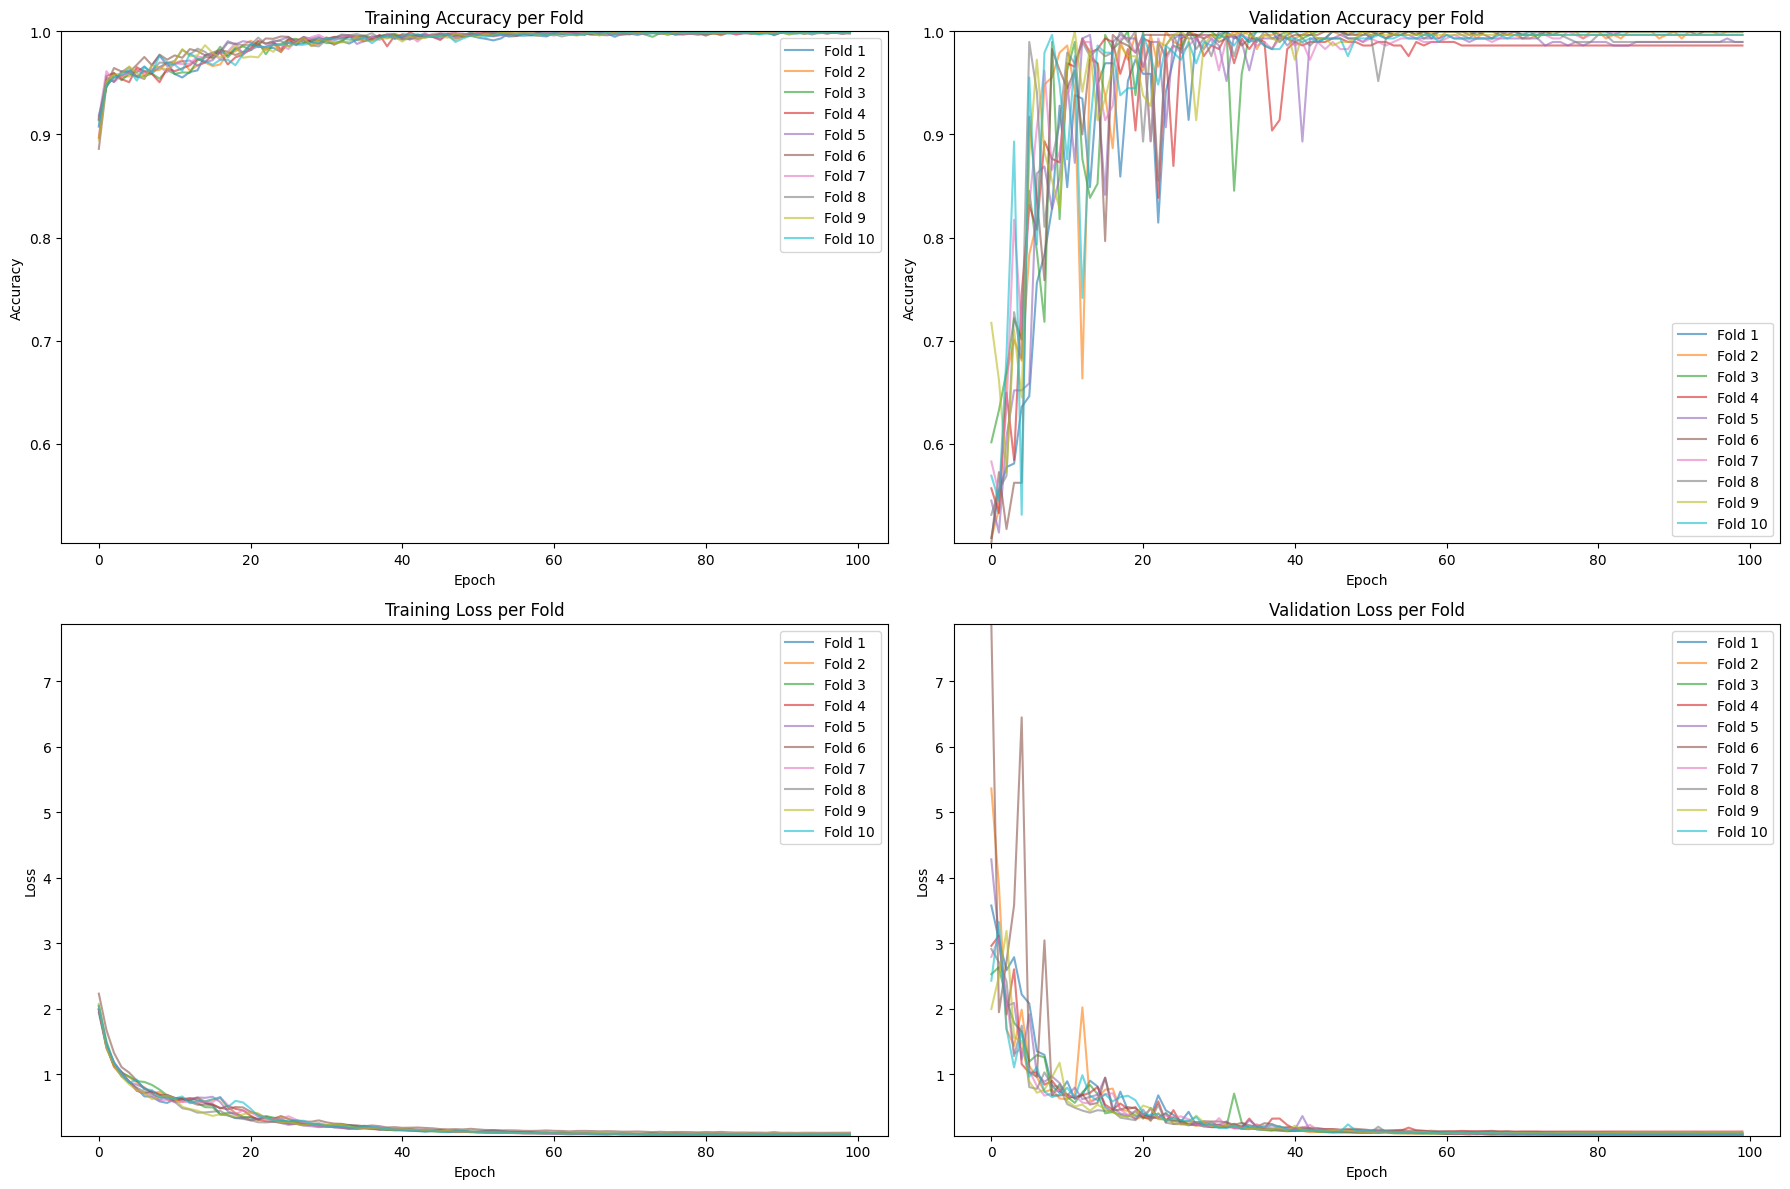

Plot saved to: /content/drive/My Drive/DEG project/cnn_10fold_training accuracy&loss.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.callbacks import ReduceLROnPlateau
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Assuming X and y are your data and labels (replace with your actual data)
X = X_train_resampled
y = y_train_resampled

# 10-Fold Cross Validation
n_folds = 10
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize storage lists
train_accuracies, val_accuracies = [], []
train_losses, val_losses = [], []
test_accuracies = []

# Callback
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'\nFold {fold + 1}/{n_folds}')

    # Split data
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Reshape for Conv1D
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

    # Build CNN Model
    model = Sequential([
        Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1], 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(256, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(512, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    # Compile model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[reduce_lr],
        verbose=1
    )

    # Store metrics
    train_accuracies.append(history.history['accuracy'])
    val_accuracies.append(history.history['val_accuracy'])
    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])

    # Validation accuracy
    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    test_accuracies.append(accuracy)
    print(f"Fold {fold + 1} Validation Accuracy: {accuracy:.4f}")

# Summary
mean_test_accuracy = np.mean(test_accuracies)
std_test_accuracy = np.std(test_accuracies)
print(f"\nMean Validation Accuracy: {mean_test_accuracy:.4f} (+/- {std_test_accuracy:.4f})")


max_epochs = max(len(acc) for acc in train_accuracies)

# Pad all histories to equal length
for i in range(n_folds):
    if len(train_accuracies[i]) < max_epochs:
        pad_len = max_epochs - len(train_accuracies[i])
        train_accuracies[i] += [train_accuracies[i][-1]] * pad_len
        val_accuracies[i] += [val_accuracies[i][-1]] * pad_len
        train_losses[i] += [train_losses[i][-1]] * pad_len
        val_losses[i] += [val_losses[i][-1]] * pad_len

# Get global y-axis limits
acc_min = min(min(min(train_accuracies)), min(min(val_accuracies)))
acc_max = max(max(max(train_accuracies)), max(max(val_accuracies)))
loss_min = min(min(min(train_losses)), min(min(val_losses)))
loss_max = max(max(max(train_losses)), max(max(val_losses)))

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# Train Accuracy
for fold in range(n_folds):
    axs[0, 0].plot(train_accuracies[fold], label=f'Fold {fold+1}', alpha=0.6)
axs[0, 0].set_title("Training Accuracy per Fold")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Accuracy")
axs[0, 0].set_ylim(acc_min, acc_max)
axs[0, 0].legend()

# Validation Accuracy
for fold in range(n_folds):
    axs[0, 1].plot(val_accuracies[fold], label=f'Fold {fold+1}', alpha=0.6)
axs[0, 1].set_title("Validation Accuracy per Fold")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Accuracy")
axs[0, 1].set_ylim(acc_min, acc_max)
axs[0, 1].legend()

# Train Loss
for fold in range(n_folds):
    axs[1, 0].plot(train_losses[fold], label=f'Fold {fold+1}', alpha=0.6)
axs[1, 0].set_title("Training Loss per Fold")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Loss")
axs[1, 0].set_ylim(loss_min, loss_max)
axs[1, 0].legend()

# Validation Loss
for fold in range(n_folds):
    axs[1, 1].plot(val_losses[fold], label=f'Fold {fold+1}', alpha=0.6)
axs[1, 1].set_title("Validation Loss per Fold")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Loss")
axs[1, 1].set_ylim(loss_min, loss_max)
axs[1, 1].legend()

plt.tight_layout()
